In [1653]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# 1-Qubit case

In [ ]:
class LSZ_experiment():

    def __init__(self, n_qubits, epsilon, H_target_dictionary, ramp_time, wait_time):
        '''
        Params:
        epsilon: Coefficient of X Hamiltonian
        alpha: Coefficient of target Hamiltonian
        total_time: Total time of the algorithm
        wait_time: Waiting time in the middle of the LSZ algorithm (0 if just doing LZ)
        max_s: maximum of s parameter. Will control slope of schedule
        '''

        self.n_qubits = n_qubits
        self.e = epsilon
        self.Ht_dict = H_target_dictionary

        self.to =  0
        self.tw = wait_time
        self.tr = ramp_time
        
        self.tf = 2*self.tr + self.tw
       
        self.slope = 1/self.tr

        self.npsx, self.npsy, self.npsz = np.array([[0, 1], [1, 0]]), np.array([[0, -1j], [1j, 0]]), np.array([[1, 0], [0, -1]])
        self.qtsx, self.qtsy, self.qtsz = qt.sigmax(), qt.sigmay(), qt.sigmaz() 

        self.ket0 = qt.basis(2, 0)
        self.ket1 = qt.basis(2, 1)


        self.qtsx_list, self.qtsy_list, self.qtsz_list = self.initialize_qt_operators()
        self.npsx_list, self.npsy_list, self.npsz_list = self.initialize_np_operators()

        self.H0_numpy = self.build_H0_numpy()
        self.H0_qutip = self.build_H0_qutip()

        self.Ht_numpy = self.build_Ht_numpy()
        self.Ht_qutip = self.build_Ht_qutip()

    
    def kron_n(ops):
        '''Tensor product of a list of operators'''
        out = ops[0]
        for A in ops[1:]:
            out = np.kron(out, A)
        return out
    
    def build_H0_numpy(self):
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        for i in range(self.n_qubits):
            H += -self.e*self.npsx_list[i]
        return H

    def build_H0_qutip(self):
        H = 0
        for i in range(self.n_qubits):
            H += -self.e*self.qtsx_list[i]
        return H
    
    def build_Ht_numpy(self):
        #Initialize Hamiltonian
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.npsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[i+j-1]*self.npsz_list[i] @ self.npsz_list[j]

        return H

    def build_Ht_qutip(self):
        #Initialize Hamiltonian
        H = 0
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.qtsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[i+j-1]*self.qtsz_list[i] * self.qtsz_list[j]

        return H

    def initialize_np_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.npsx, self.npsy, self.npsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [np.qeye(2)] * self.n_qubits
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(self.kron_n(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(self.kron_n(op_list))
            op_list[i] = sz
            sz_list.append(self.kron_n(op_list))

        return sx_list, sy_list, sz_list

    def initialize_qt_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.qtsx, self.qtsy, self.qtsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [qt.qeye(2)] * self.n_qubits
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(qt.tensor(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(qt.tensor(op_list))
            op_list[i] = sz
            sz_list.append(qt.tensor(op_list))

        return sx_list, sy_list, sz_list


    def trapezoid_s(self, t):
        return np.minimum(1, self.slope * np.minimum(t, self.tf - t))

    def H_numpy(self, t):
        s = self.trapezoid_s(t)
        return (1-s)*self.H0_numpy + self.a*s*self.Ht_numpy
    
    def H_qutip(self):

        H = [[self.H0_qutip, lambda t, args: 1 - self.trapezoid_s(t)], [self.Ht_qutip, lambda t, args: self.trapezoid_s(t)]]

        return H
    
    
    def show_schedule(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        s_list = np.zeros(len(t_list))

        for i,t in enumerate(t_list):
            s_list[i] = self.trapezoid_s(t)
        
        return t_list, s_list
    
    def show_spectrum(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        eg_val_list = []
        eg_vec_list = []

       #Diagonalize for each time step 
        for i,t in enumerate(t_list):
            H = self.H_numpy(self.Ht_numpy, t)
            egvals, egvecs = np.linalg.eigh(H)

            eg_val_list.append(egvals)
            eg_vec_list.append(egvecs)

        return t_list, eg_val_list, eg_vec_list
    

    def time_evolution(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)

        #Prepare ground state of H at time 0
        psi0 = 1/np.sqrt(2)*(self.ket0 + self.ket1)

        #Initialize qutip Hamiltonian
        H = self.H_qutip(self.Ht_qutip)

        #Time evolution
        return qt.sesolve(H, psi0, t_list)
    
    def calculate_populations(self, sim_res):

        final_state = sim_res.states[-1]

        H_f = self.H_numpy(self.Ht_numpy, self.tf)
        eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

        dot_c = np.dot(final_state.full().flatten(), eigvecs_f[0])
        dot_e = np.dot(final_state.full().flatten(), eigvecs_f[1])

        pc = dot_c*dot_c.conj()
        pe = dot_e*dot_e.conj()

        return pc, pe



- Ramp time controls the speed that we use to bring the system to the middle point. The faster, the higher the transition probability.

- High ramp time makes oscillations larger

- for LZ we ramp and pass the crossing once. For LZS you cross the gap twice. during wait time, s=1, no transverse term. Start at Hx, both terms evolve.

In [ ]:
nqubits = 1
epsilon = 5
alpha = 1.5

ramp_time = 1

n_steps = 101

max_wait_time = 50.0/alpha
n_sims = int(max_wait_time*20)

tw_l = np.linspace(0, max_wait_time, n_sims)
pc_list = []
pe_list = []

local_z_list = np.array([1.5])
zz_terms = np.array()
H_target_dict = {'one_body': local_z_list, 'two_body': zz_terms}

wait_test = 1
test =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_test)



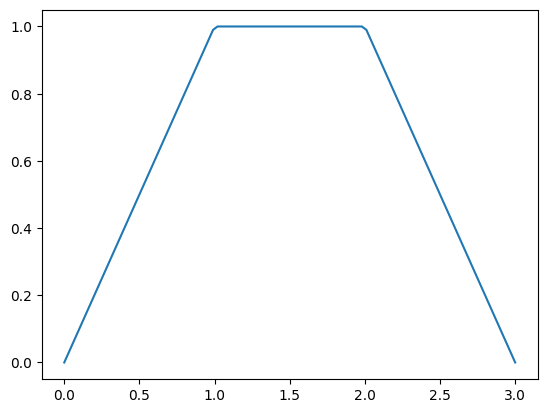

In [1666]:
t_list, s_list = test.show_schedule(n_steps)
plt.plot(t_list, s_list)

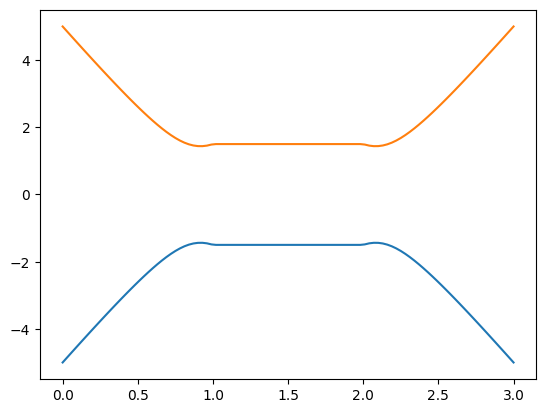

In [1667]:
t_list, egvals, egvecs = test.show_spectrum(n_steps)
plt.plot(t_list, egvals)

In [1658]:
for wait_time in tw_l:
    experiment =LSZ_experiment(nqubits, alpha, epsilon, ramp_time, wait_time)

    result = experiment.time_evolution(n_steps)

    pc, pe = experiment.calculate_populations(result)

    pc_list.append(np.real(pc))
    pe_list.append(np.real(pe))

## Next steps:

0. Fixed code to do the right thing --DONE

1. Extract frequency and epsilon from oscillations --DONE

2. Test for 2 qubit system. Modify class to take in number of qubits external target Hamiltonian

3. Test interferometry for 2, 3 qubit systems

4. Look at ordering of energies, like how Matthias does it

In [1659]:
def fourier_analysis(pc_list, tw_l):
    """
    Absolute simplest Fourier analysis - just 2 plots
    """
    y = np.array(pc_list)
    t = np.array(tw_l)
    
    # Basic calculations
    N = len(y)
    dt = t[1] - t[0]
    
    # FFT
    spectrum = np.fft.fft(y)
    freqs = np.fft.fftfreq(N, dt)
    magnitude = np.abs(spectrum)
    
    # Find peak frequency (excluding DC component at f=0)
    positive_idx = np.where(freqs > 0)[0]
    # Exclude the first positive frequency if it's very close to 0
    # or start from a minimum threshold
    min_freq_threshold = 0.01 * np.max(freqs[positive_idx])  # adjustable threshold
    valid_idx = positive_idx[freqs[positive_idx] > min_freq_threshold]
    
    peak_idx = valid_idx[np.argmax(magnitude[valid_idx])]
    dominant_freq = freqs[peak_idx]
    amplitude = 2 * magnitude[peak_idx] / N
    
    # Create figure
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Original signal
    plt.subplot(1, 2, 1)
    plt.plot(t, y, 'b-', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Signal')
    plt.title(f'Original Signal\nFrequency ≈ {dominant_freq:.3f}')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Fourier spectrum (excluding DC or starting from small freq)
    plt.subplot(1, 2, 2)
    # Option 1: Plot from index 1 to skip DC
    plt.plot(freqs[1:N//2], magnitude[1:N//2], 'r-', linewidth=2)
    plt.axvline(dominant_freq, color='k', linestyle='--', 
                label=f'Peak: f={dominant_freq:.3f}\nA={amplitude:.3f}')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.title('Fourier Transform (DC removed)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Peak frequency: {dominant_freq:.6f}")
    print(f"Amplitude: {amplitude:.6f}")
    
    return dominant_freq, amplitude

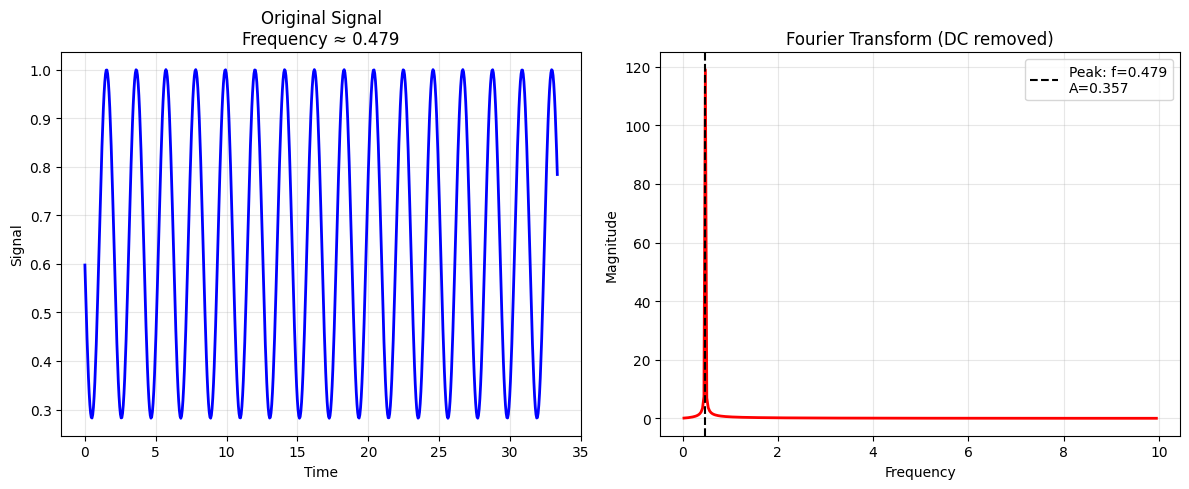

Peak frequency: 0.479279
Amplitude: 0.357474


In [1660]:
dominant_freq, amplitude = fourier_analysis(pc_list, tw_l)

In [1661]:
print("Period:", 1/dominant_freq)
alpha_rec = np.pi*dominant_freq
print('recovered alpha:', alpha_rec)

Period: 2.086466165413534
recovered alpha: 1.5057002628015943
